# Introduction

This project is meant to serve as an in-depth analysis of the music artist Coldplay's discography. Coldplay are one of today's most popular bands in many countries around the world and have sold over 100 million albums. They have had influence on music through their reinventions of rock music into a more gentle and melodic style. Therefore, it is only sensible to consider what makes this world-renowned band who they are. 

To start, their evoltuon will be analyzed, including their gradual transition away from rock and towards pop-oriented music. Then, an important question will be investigated: what makes the band so popular? Various recorded features of their music will be considered. Finally, Coldplay is knowne for having generally positive-sounding music. What characterizes these songs and how do they tie into their popularity? 

The dataset used was taken from the following site: https://www.kaggle.com/datasets/faizalkarim/coldplay-albums-and-live-shows. It includes a comprehensive set of their music, including deluxe versions of their studio albums. The dataset originates from data collected by Spotify, which includes many different characteristics of each song, including the album, popularity, duration, tempo, and many others.

# Data Cleaning

First, the proper Python libraries will be imported, including pandas for data manipulation, matplotlib and seaborn for visualization, and numpy and scipy for various mathematical and statistical uses. The data is then imported from the csv file.

In [430]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

df = pd.read_csv("../data/Coldplay.csv")

df.sort_index(ascending=False)

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
231,Everything's Not Lost - Includes Hidden Track ...,436.440,2000-07-10,Parachutes,False,61,0.104000,0.3740,0.4560,0.000176,0.1970,-7.350,0.0368,135.643,4,0.0763
230,We Never Change,249.400,2000-07-10,Parachutes,False,65,0.535000,0.4330,0.2880,0.000169,0.1050,-10.801,0.0296,136.939,3,0.1310
229,High Speed,256.466,2000-07-10,Parachutes,False,65,0.396000,0.4950,0.5250,0.007360,0.0961,-9.342,0.0301,154.466,4,0.2490
228,Parachutes,46.200,2000-07-10,Parachutes,False,62,0.871000,0.5550,0.0845,0.000002,0.1380,-18.348,0.0518,137.001,4,0.3750
227,Trouble,273.426,2000-07-10,Parachutes,False,75,0.189000,0.5650,0.5460,0.001500,0.1700,-7.496,0.0314,139.757,4,0.1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Let Somebody Go,241.595,2021-10-15,Music Of The Spheres,False,76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4,0.1550
3,✨,53.033,2021-10-15,Music Of The Spheres,False,59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4,0.0380
2,Humankind,266.704,2021-10-15,Music Of The Spheres,False,68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4,0.2150
1,Higher Power,206.681,2021-10-15,Music Of The Spheres,False,71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4,0.4850


Before investigating the data, the datatypes are checked to see if they fit analysis needs.

In [431]:
df.dtypes

name                    str
duration            float64
release_date            str
album_name              str
explicit               bool
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
dtype: object

Two problems stand out. Firstly, time_signature should be a string and not a float, since time signatures are better interpreted as categories of numbers of beats rather than true numbers. It's also more informative to display the full time signature rather than just the number of beats, for example 3 -> 3/4.

In [432]:
df["time_signature"] = df["time_signature"].astype(str) + "/4"

df.dtypes

name                    str
duration            float64
release_date            str
album_name              str
explicit               bool
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
time_signature          str
valence             float64
dtype: object

In [433]:
df["time_signature"].head()

0    4/4
1    4/4
2    4/4
3    4/4
4    4/4
Name: time_signature, dtype: str

The other problem is that release_date should be a datetime to allow for plotting on line charts. 

In [434]:
df["release_date"] = pd.to_datetime(df["release_date"])
df.dtypes

name                           str
duration                   float64
release_date        datetime64[us]
album_name                     str
explicit                      bool
popularity                   int64
acousticness               float64
danceability               float64
energy                     float64
instrumentalness           float64
liveness                   float64
loudness                   float64
speechiness                float64
tempo                      float64
time_signature                 str
valence                    float64
dtype: object

Another issue is that popularity has values on a scale between 0 and 100, but many other numeric features are between 0.0 and 1.0. To keep it consistent with the other features and allow for cleaner visualization, it will be rescaled to between 0.0 and 1.0.

In [435]:
df["popularity"] = df["popularity"] / 100
df["popularity"].describe()

count    232.000000
mean       0.433621
std        0.211158
min        0.000000
25%        0.230000
50%        0.440000
75%        0.590000
max        0.910000
Name: popularity, dtype: float64

Next, possible whitespaces are checked to avoid duplicate results.

In [436]:
str_cols = df.select_dtypes(include=str).columns

df[str_cols] = df[str_cols].apply(lambda x: x.str.strip(), axis=0)

In [437]:
df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                      'Live in Buenos Aires',
                             'Love in Tokyo',
                     'A Head Full of Dreams',
        'A Head Full of Dreams Tour Edition',
                   'Ghost Stories Live 2014',
                             'Ghost Stories',
                                 'Live 2012',
                               'Mylo Xyloto',
             'LeftRightLeftRightLeft (Live)',
   'Viva La Vida (Prospekt's March Edition)',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
                                 'Live 2003',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 17, dtype: str

As shown above, the dataset contains live performances as well as the studio albums. Since live performances differ very little from the studio variants, they will be removed to avoid song duplicates. Note that their latest studio album, Moon Music, is not present in the dataset as the dataset was last updated 3 years ago.

In [438]:
df = df[df["album_name"].isin(['Music Of The Spheres',
                               'Everyday Life',
                               'A Head Full of Dreams',
                               'Ghost Stories',
                               'Mylo Xyloto',
                               'Viva La Vida or Death and All His Friends',
                               'X&Y',
                               'A Rush of Blood to the Head',
                               'Parachutes'])]

df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                     'A Head Full of Dreams',
                             'Ghost Stories',
                               'Mylo Xyloto',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 9, dtype: str

Now let's check for duplicates across all columns and specifically for the name column which shouldn't have duplicates.

In [439]:
print(df.duplicated().any())
print(df.duplicated(["name"]).any())

False
False


None can be found. Now let's check for possible missing values and empty strings.

In [440]:
print(df.isna().any(axis=1).any(axis=0))

False


In [441]:
df.apply(lambda x: x == "", axis=1).any(axis=0)

name                False
duration            False
release_date        False
album_name          False
explicit            False
popularity          False
acousticness        False
danceability        False
energy              False
instrumentalness    False
liveness            False
loudness            False
speechiness         False
tempo               False
time_signature      False
valence             False
dtype: bool

Again, none found. 

The indices no longer align with the length of the DataFrame, so it will be reindexed.

In [442]:
df.reset_index(drop=True, inplace=True)

df

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
0,🪐,53.184,2021-10-15,Music Of The Spheres,False,0.62,0.887000,0.3260,0.3220,0.841000,0.1160,-20.192,0.0337,89.657,4/4,0.0651
1,Higher Power,206.681,2021-10-15,Music Of The Spheres,False,0.71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4/4,0.4850
2,Humankind,266.704,2021-10-15,Music Of The Spheres,False,0.68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4/4,0.2150
3,✨,53.033,2021-10-15,Music Of The Spheres,False,0.59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4/4,0.0380
4,Let Somebody Go,241.595,2021-10-15,Music Of The Spheres,False,0.76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4/4,0.1550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Trouble,273.426,2000-07-10,Parachutes,False,0.75,0.189000,0.5650,0.5460,0.001500,0.1700,-7.496,0.0314,139.757,4/4,0.1950
108,Parachutes,46.200,2000-07-10,Parachutes,False,0.62,0.871000,0.5550,0.0845,0.000002,0.1380,-18.348,0.0518,137.001,4/4,0.3750
109,High Speed,256.466,2000-07-10,Parachutes,False,0.65,0.396000,0.4950,0.5250,0.007360,0.0961,-9.342,0.0301,154.466,4/4,0.2490
110,We Never Change,249.400,2000-07-10,Parachutes,False,0.65,0.535000,0.4330,0.2880,0.000169,0.1050,-10.801,0.0296,136.939,3/4,0.1310


One may notice that there're strange emojis present in the name column. These are stylistic depictions of songs in the album Music of the Spheres.

In [443]:
df["name"].sort_values(ascending=False).head(10)

0            🪐
8            🌎
5           ❤️
3            ✨
10           ♾
25     بنی آدم
22         Èkó
72         Yes
106     Yellow
83         X&Y
Name: name, dtype: str

The actual names of the songs would be more helpful, so they will be individually replaced.

In [444]:
df.loc[[0, 8, 5, 3, 10, 25], "name"] = ["Music of the Spheres", "Music of the Spheres II", "Human Heart", "Alien Choir", "Infinity Sign", "Bani Adam"]

In [445]:
df[df["album_name"] == "Music Of The Spheres"]

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
0,Music of the Spheres,53.184,2021-10-15,Music Of The Spheres,False,0.62,0.887000,0.3260,0.3220,0.841000,0.1160,-20.192,0.0337,89.657,4/4,0.0651
1,Higher Power,206.681,2021-10-15,Music Of The Spheres,False,0.71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4/4,0.4850
2,Humankind,266.704,2021-10-15,Music Of The Spheres,False,0.68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4/4,0.2150
3,Alien Choir,53.033,2021-10-15,Music Of The Spheres,False,0.59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4/4,0.0380
4,Let Somebody Go,241.595,2021-10-15,Music Of The Spheres,False,0.76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4/4,0.1550
5,Human Heart,188.966,2021-10-15,Music Of The Spheres,False,0.65,0.970000,0.3480,0.0491,0.000186,0.0918,-15.431,0.0404,136.680,1/4,0.2320
6,People of The Pride,217.266,2021-10-15,Music Of The Spheres,True,0.66,0.005810,0.4320,0.6130,0.015100,0.3120,-6.785,0.0349,136.362,4/4,0.0911
7,Biutyful,192.394,2021-10-15,Music Of The Spheres,False,0.66,0.016800,0.6140,0.6800,0.000560,0.1180,-7.840,0.0425,153.937,4/4,0.3470
8,Music of the Spheres II,21.388,2021-10-15,Music Of The Spheres,False,0.19,0.969000,0.1150,0.9070,0.981000,0.9800,-20.358,0.2230,189.885,3/4,0.0185
9,My Universe,226.198,2021-10-15,Music Of The Spheres,False,0.84,0.011400,0.5730,0.7110,0.000000,0.3280,-6.268,0.0406,105.006,4/4,0.4700


Now the values of the columns will be checked for any invalid data. The following columns should only have values between 0.0 and 1.0.

In [446]:
columns = ['popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']

print(df[columns].min(), "\n")
print(df[columns].max())

popularity          0.000000
acousticness        0.000114
danceability        0.085900
energy              0.049100
instrumentalness    0.000000
liveness            0.035900
speechiness         0.024300
valence             0.018500
dtype: float64 

popularity          0.910
acousticness        0.970
danceability        0.738
energy              0.924
instrumentalness    0.990
liveness            0.980
speechiness         0.248
valence             0.802
dtype: float64


The other features are graphed to visuzlize their distributions and see if they're in order.

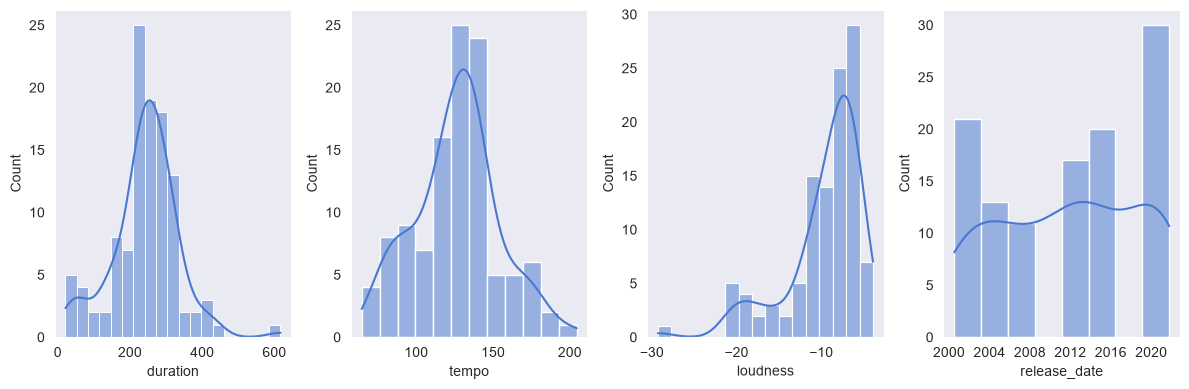

In [447]:
sns.set_style("dark")
sns.set_palette("muted")

fig, ax = plt.subplots(1, 4, figsize=(12, 4))

sns.histplot(x="duration", data=df, kde=True, ax=ax[0])
sns.histplot(x="tempo", data=df, kde=True, ax=ax[1])
sns.histplot(x="loudness", data=df, kde=True, ax=ax[2])
sns.histplot(x="release_date", data=df, kde=True, ax=ax[3])

plt.tight_layout()
plt.show()

Everything seems to fit expectations. Perhaps something initially suspicious is that there's a song around 600 seconds (ten minutes) long, however the song Coloratura is actually that long and thus it's not a mistake.

# Coldplay's Evolution

Coldplay has amassed a diverse discography over the years spanning several subgenres of rock and pop. In particular, Coldplay is known for having transitioned from rock music in their earlier studio albums gradually into pop music in the modern-day. Let's see if this is evident in the characteristics of their music over time.

Firstly, their first two albums are known as being acoustic rock, while they later transitioned into using more electronic instrumentation characteristic of pop.

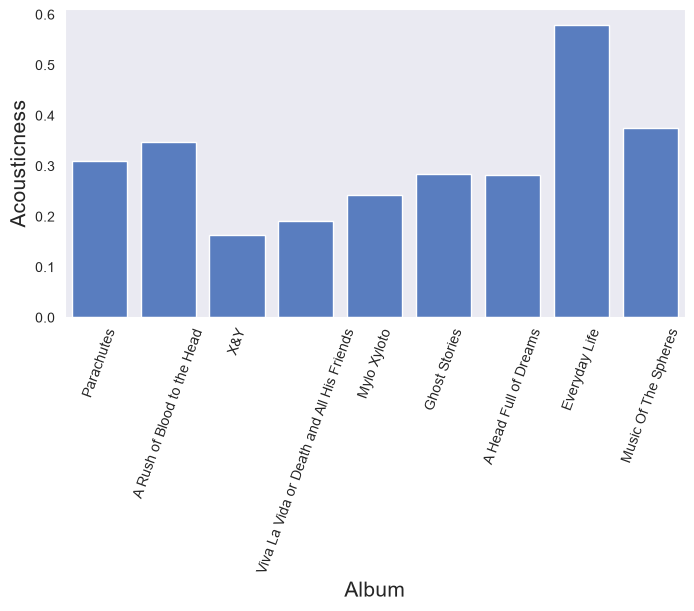

In [448]:
ordered_df = df.sort_values(by=["release_date"])

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="acousticness", data=ordered_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Acousticness", fontsize=15)
plt.xticks(rotation=70)

plt.show()

Indeed, the first two albums are more acoustic than later. Only with Everyday Life did they increase the acousticness of their music. 

Pop music is generally more energetic than acoustic rock, so perhaps the energy level increased.

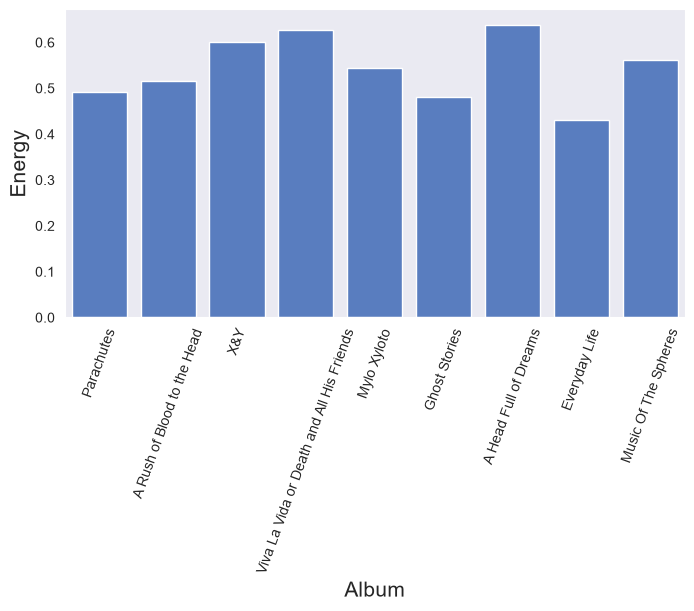

In [449]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="energy", data=ordered_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
plt.xticks(rotation=70)

plt.show()

This roughly lines up with expectations, with energy generally to trend upward. Exceptions such as Ghost Stories and Everyday Life do exist, as they were made with the intention of being more mellow. Of course, all albums have exceptions and wide ranges in energy, as shown below.

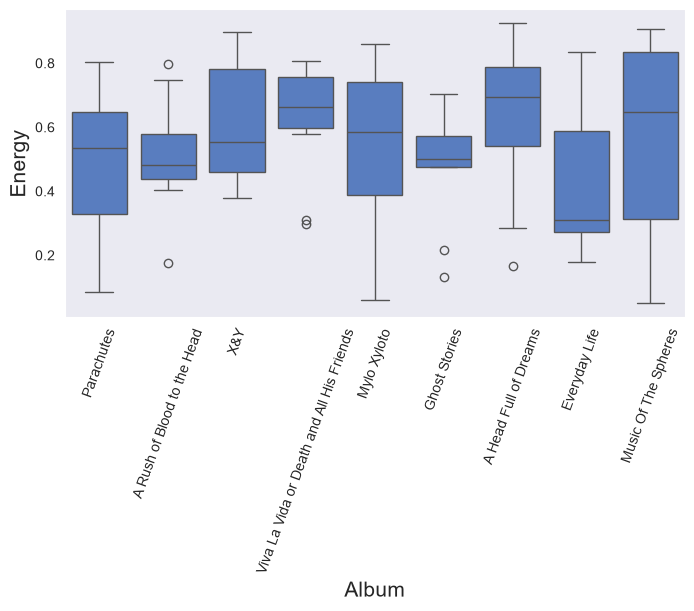

In [450]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x="album_name", y="energy", data=ordered_df)
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
plt.xticks(rotation=70)

plt.show()

Albums typically considered to be energetic, such as Viva la Vida, have mellow tracks that act as outliers, such as Death And ALl His Friends. Similarily in A Rush of Blood to the Head, Clocks is significantly more energetic most of the other songs in the album. This shows that typcal album associations don't always hold for each indivdual song and that Coldplay has created great variety even within individual albums.

In [451]:
sub_df = ordered_df.query("album_name == 'Viva La Vida or Death and All His Friends' | album_name ==  'A Rush of Blood to the Head'")
sub_df[["album_name", "name", "energy"]]

,album_name,name,energy
91,A Rush of Blood to the Head,Politik,0.482
92,A Rush of Blood to the Head,In My Place,0.588
93,A Rush of Blood to the Head,God Put a Smile upon Your Face,0.556
94,A Rush of Blood to the Head,The Scientist,0.442
95,A Rush of Blood to the Head,Clocks,0.749
97,A Rush of Blood to the Head,Green Eyes,0.405
98,A Rush of Blood to the Head,Warning Sign,0.433
99,A Rush of Blood to the Head,A Whisper,0.797
100,A Rush of Blood to the Head,A Rush of Blood to the Head,0.472
101,A Rush of Blood to the Head,Amsterdam,0.176


Finally, one would assume that an increase in energy would mean faster music and therefore a greater tempo.

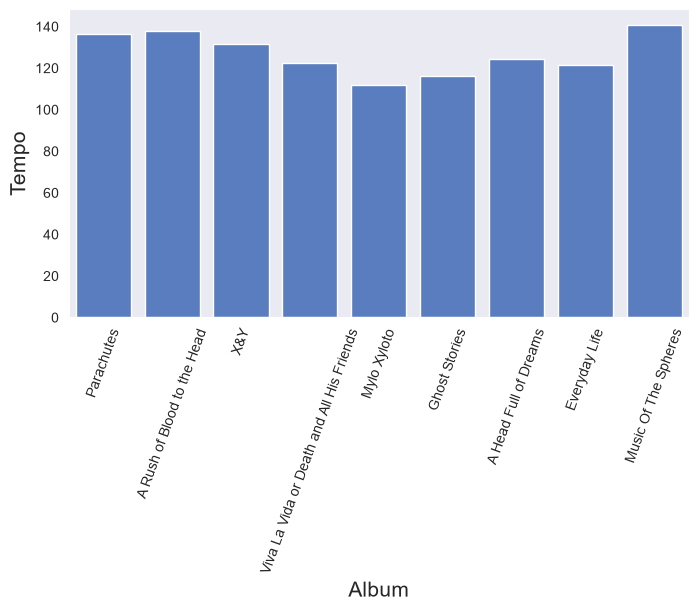

In [452]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="tempo", data=ordered_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Tempo", fontsize=15)
plt.xticks(rotation=70)

plt.show()

However the data seems to suggest the opposite. Tempo seemed to decrease with time, with the exception of Music Of The Spheres. Ironically, Parachutes and A Rush of Blood to the Head, some of their least energetic albums, have some of the fastest average tempos. This suggests that Spotify's energy metric captures aspects of a song beyond speed, such as loudness and production style. This can be seen when tempo and energy are compared directly.

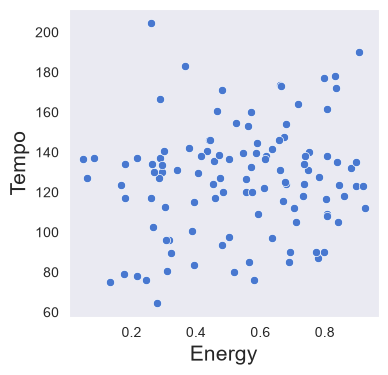

In [453]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(x="energy", y="tempo", data=ordered_df)
ax.set_xlabel("Energy", fontsize=15)
ax.set_ylabel("Tempo", fontsize=15)

plt.show()

There seems to be no significant relationship between the two, further proving that high energy in Coldplay's music isn't dependant on high tempo. Let's see if the increase in energy is due to denser instrumentation and generally being louder.

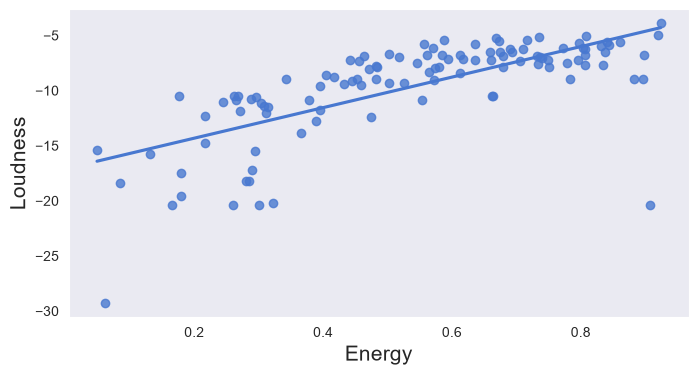

In [454]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.regplot(x="energy", y="loudness", data=ordered_df, ci=False)
ax.set_xlabel("Energy", fontsize=15)
ax.set_ylabel("Loudness", fontsize=15)

plt.show()

As expected, Coldplay's more energetic songs tend to be louder. This seems to explain the increase in energy, rather than tempo.

To conclude, many insights can be drawn regarding Coldplay's evolution. Generally speaking, their music became less acoustic, more energetic, less fast, and more loud with time. However, albums like Ghost Stories and Everyday Life defy some of these trends. Therefore, Coldplay's evolution can't be accurately summarized as simply following certain trends without acknowledging that their experimentation and genre-blending leads to much of their music defying certain assumptions.

# Coldplay's Popular Songs